# Toy DAG demo

Four `Source` artifacts (real Project Gutenberg texts) feeding a `Tokenizer`
trained on three of them, a `TokenizedSource` per source, a `DataSet` for the
run, and the run's `Pretraining` output.

Every artifact owns one folder; its files and its manifest both live there.
Jobs take their inputs from `deps()` -- nothing about "which sources feed the
tokenizer" is declared on the job itself.

In [1]:
from pathlib import Path

from artifact import (
    Source,
    Tokenizer,
    TokenizedSource,
    DataSet,
    Pretraining,
    PretrainingConfig,
)
from resolve import job_list, resolve, run_all, producer_for, manifest_json
from visualizer import visualize

root = Path("../data_demo")  # kept separate from the real /data tree

In [2]:
odyssey = Source(
    name="odyssey", url="https://www.gutenberg.org/cache/epub/1727/pg1727.txt"
)
mobydick = Source(
    name="mobydick", url="https://www.gutenberg.org/cache/epub/2701/pg2701.txt"
)
romeojuliet = Source(
    name="romeojuliet", url="https://www.gutenberg.org/cache/epub/1513/pg1513.txt"
)
montecristo = Source(
    name="montecristo", url="https://www.gutenberg.org/cache/epub/1184/pg1184.txt"
)

In [3]:
RUN_ID = "toy"

tokenizer = Tokenizer(
    vocab_size=50,
    kind="bpe",
    special_tokens=("<pad>", "<unk>"),
    sources=(odyssey, mobydick, montecristo),
)

training_split = DataSet.from_sources(
    run_id=RUN_ID,
    tokenizer=tokenizer,
    train_sources=[
        odyssey,
        mobydick,
    ],
    valid_sources=[
        romeojuliet,
        montecristo,
    ],
)

pretraining = Pretraining(
    run_id=RUN_ID,
    dataset=training_split,
    tokenizer=tokenizer,
    config=PretrainingConfig(
        hidden_size=64, num_layers=2, lr=1e-3, seed=1, checkpoint_every=250
    ),
    step=1000,
)

manifest = resolve(pretraining)
job_list(manifest)

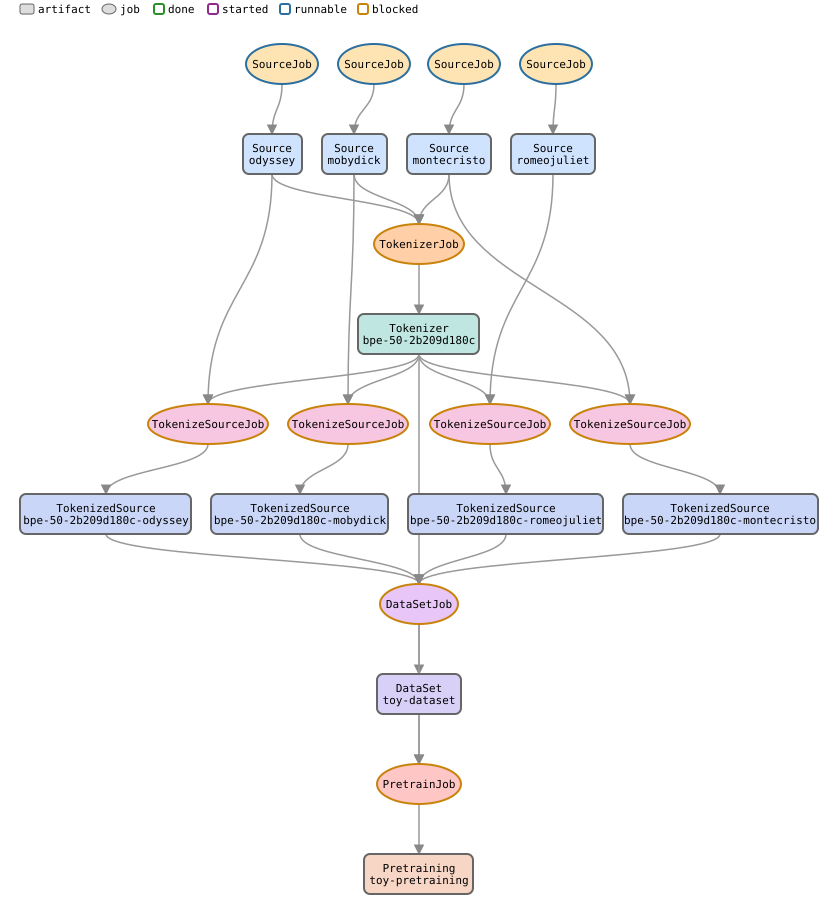

In [4]:
visualize(manifest, root)  # all green now

In [5]:
run_all(pretraining, root)

run   sources/odyssey
run   sources/mobydick
run   sources/montecristo
run   tokenizers/bpe-50-2b209d180c
run   tokenizers/bpe-50-2b209d180c/bin/odyssey
run   tokenizers/bpe-50-2b209d180c/bin/mobydick
run   sources/romeojuliet
run   tokenizers/bpe-50-2b209d180c/bin/romeojuliet
run   tokenizers/bpe-50-2b209d180c/bin/montecristo
run   runs/toy/dataset
run   runs/toy/pretraining


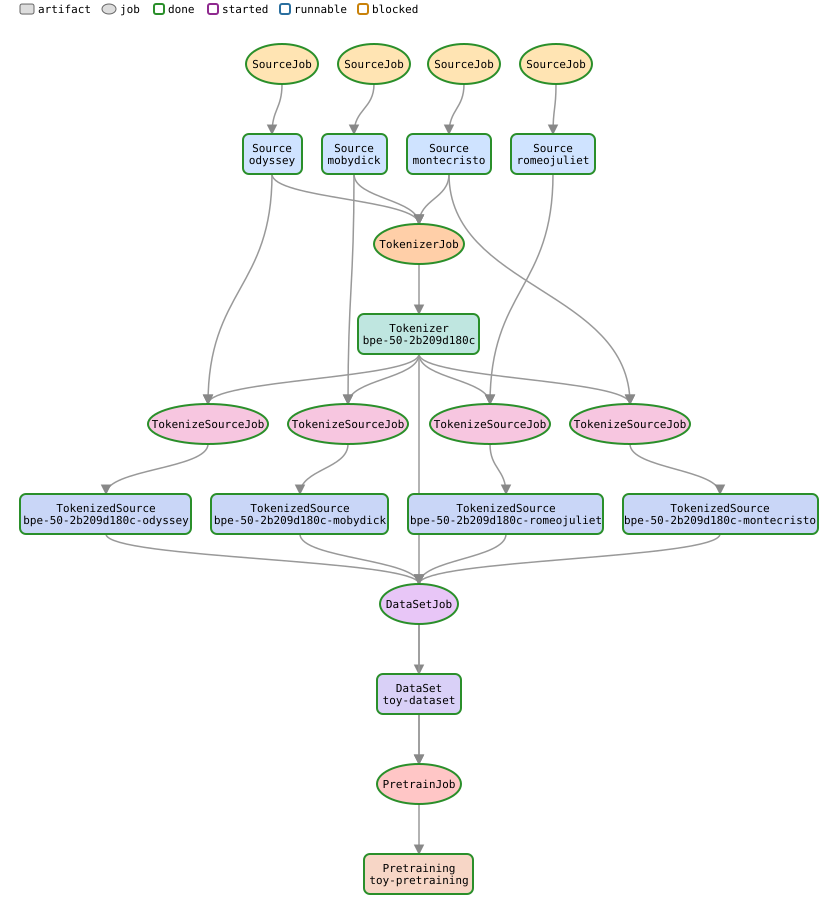

In [6]:
visualize(manifest, root)  # all gree/n now

In [7]:
manifest_json(manifest)  # exactly what gets written into each folder

{'artifact': 'Pretraining',
 'uid': 'toy-pretraining',
 'artifact_path': 'runs/toy/pretraining',
 'files': {'step 250': 'checkpoint_250.txt',
  'step 500': 'checkpoint_500.txt',
  'step 750': 'checkpoint_750.txt',
  'step 1000': 'checkpoint_1000.txt'},
 'job': 'PretrainJob',
 'dependencies': [{'artifact': 'DataSet',
   'uid': 'toy-dataset',
   'artifact_path': 'runs/toy/dataset',
   'files': {'training set': 'train.bin', 'validation set': 'valid.bin'},
   'job': 'DataSetJob',
   'dependencies': [{'artifact': 'TokenizedSource',
     'uid': 'bpe-50-2b209d180c-odyssey',
     'artifact_path': 'tokenizers/bpe-50-2b209d180c/bin/odyssey',
     'files': {'tokens': 'tokens.bin'},
     'job': 'TokenizeSourceJob',
     'dependencies': [{'artifact': 'Tokenizer',
       'uid': 'bpe-50-2b209d180c',
       'artifact_path': 'tokenizers/bpe-50-2b209d180c',
       'files': {'tokenizer': 'tokenizer.json'},
       'job': 'TokenizerJob',
       'dependencies': [{'artifact': 'Source',
         'uid': 'odyss